In [20]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [21]:
import pandas as pd
import numpy as np 
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
import cv2
import os
import matplotlib.pyplot as plt
import torch.optim as optim
from darts_dataset import SyntheticDataset, RealWorldDataset
from darts_model import CNNTransformer, DomainDiscriminator, loss_points, loss_labels, match, NUM_QUERIES, NUM_LABELS
from score import get_score, fields
from tqdm import tqdm

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [23]:
len(fields)

63

In [ ]:
BATCH_SIZE=16
# BATCH_SIZE_UNLABELED=4
DATA_DIRECTORY = "./3D/data"
LABELS_FILENAME = "combined_datasets.pkl"
LABELS_FILEPATH = os.path.join(DATA_DIRECTORY, LABELS_FILENAME)

In [25]:
# deepdarts_dataset = pd.read_pickle("labels/labels.pkl")
# df = pd.concat([deepdarts_dataset[["img_folder", "img_name", "xy"]], pd.read_pickle(LABELS_FILEPATH)], ignore_index=True)
# df.to_pickle("./3D/labels_combined.pkl")

In [26]:
df=pd.read_pickle(LABELS_FILEPATH)
# df = df[:-7]
# df[df["img_folder"] == "C:/Users/Tim/Documents/dev/playdarts/3D/imgs_0002"] = df[df["img_folder"] == "C:/Users/Tim/Documents/dev/playdarts/3D/imgs_0002"][7:]
# df = df.dropna(subset=['img_folder'])
print(len(df))
df.tail()

33368


,img_folder,img_name,xy
16045,d2_04_05_2020,DSC_0507.JPG,"[[0.4369087750204756, 0.1419047415543067], [0...."
16046,d2_04_05_2020,DSC_0508.JPG,"[[0.4369087750204756, 0.1419047415543067], [0...."
16047,d2_04_05_2020,DSC_0509.JPG,"[[0.4369087750204756, 0.1419047415543067], [0...."
16048,d2_04_05_2020,DSC_0510.JPG,"[[0.4369087750204756, 0.1419047415543067], [0...."
16049,d2_04_05_2020,DSC_0511.JPG,"[[0.4369087750204756, 0.1419047415543067], [0...."


In [ ]:
# df.to_pickle("./3D/labels.pkl")
IMAGE_SIZE = 480

In [28]:
transform_src = transforms.Compose([
    transforms.ToTensor(),          # Convert to tensor (scales pixel values to [0,1])
    transforms.Resize(IMAGE_SIZE),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),  
    transforms.GaussianBlur(kernel_size=3),  # Simulate blur/noise  
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet mean
                         std=[0.229, 0.224, 0.225])   # ImageNet std
])
transform_tgt = transforms.Compose([
    transforms.ToTensor(),   
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.8, 1.0)),  
    transforms.ColorJitter(brightness=0.2, contrast=0.2),  
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3)], p=0.3), 
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet mean
                         std=[0.229, 0.224, 0.225])   # ImageNet std
])

In [29]:
_transform = transforms.Compose([
    transforms.ToTensor(),          # Convert to tensor (scales pixel values to [0,1])
    transforms.Resize(IMAGE_SIZE),
    transforms.CenterCrop(IMAGE_SIZE),
])

In [30]:
dataset = SyntheticDataset(DATA_DIRECTORY, LABELS_FILEPATH, transform=transform_src)
_dataset = SyntheticDataset(DATA_DIRECTORY, LABELS_FILEPATH, transform=_transform)
target_dataset = RealWorldDataset("./my_unlabelled/vids", "./my_unlabelled/vids/image_data.csv", transform=transform_tgt)
dataloader = DataLoader(dataset, collate_fn=SyntheticDataset.collate_fn, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, persistent_workers=True, drop_last=True)
target_dataloader = DataLoader(target_dataset, batch_size=BATCH_SIZE_UNLABELED, shuffle=True, num_workers=1, persistent_workers=True, drop_last=True)

           img_folder      img_name  \
0  imgs_std10_kind0_0  img_0000.png   
1  imgs_std10_kind0_0  img_0001.png   
2  imgs_std10_kind0_0  img_0002.png   
3  imgs_std10_kind0_0  img_0003.png   
4  imgs_std10_kind0_0  img_0004.png   

                                                  xy  
0  [[0.4519217014312744, 0.1922926902770996], [0....  
1  [[0.5078747272491455, 0.08181816339492798], [0...  
2  [[0.4471089839935303, 0.0990215539932251], [0....  
3  [[0.45292484760284424, 0.2456604242324829], [0...  
4  [[0.4670245945453644, 0.2610541582107544], [0....  
           img_folder      img_name  \
0  imgs_std10_kind0_0  img_0000.png   
1  imgs_std10_kind0_0  img_0001.png   
2  imgs_std10_kind0_0  img_0002.png   
3  imgs_std10_kind0_0  img_0003.png   
4  imgs_std10_kind0_0  img_0004.png   

                                                  xy  
0  [[0.4519217014312744, 0.1922926902770996], [0....  
1  [[0.5078747272491455, 0.08181816339492798], [0...  
2  [[0.4471089839935303, 0.09902155

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


tensor([8], dtype=torch.int32) tensor([ 0,  1,  2,  3, 14])


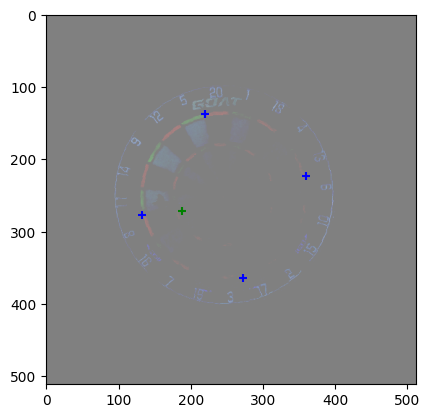

In [31]:
idx = np.random.randint(len(dataset))
image, target = dataset[idx]
_, w, h = image.shape
print(target["score"], target["labels"])
fig, ax = plt.subplots(1)
ax.imshow(image.cpu().permute(1,2,0), alpha=0.5)
ax.scatter(target["points"][:4, 0]*w, target["points"][:4, 1]*h, color='blue', s=40, marker='+', label="corners")
ax.scatter(target["points"][4:, 0]*w, target["points"][4:, 1]*h, color='green', s=40, marker='+', label="darts")

In [32]:
query_dim = 256
model = CNNTransformer(d=query_dim).to(device)
discriminator = DomainDiscriminator(query_dim, 256, 2).to(device)

C:\Users\Tim\AppData\Roaming\Python\Python312\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\Tim\AppData\Roaming\Python\Python312\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [33]:
param_dicts = [
    {"params": [p for n, p in model.named_parameters() if "backbone" not in n and p.requires_grad]},
    {
        "params": [p for n, p in model.named_parameters() if "backbone" in n and p.requires_grad],
        "lr": 1e-5,
    },
    {
        "params": [p for p in discriminator.parameters() if p.requires_grad],
    }
]

In [34]:
# model.transformer.apply(initialize_weights)
optimizer = optim.AdamW(param_dicts, lr=3e-4, weight_decay=1e-4)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, 200)

In [35]:
model.load_state_dict(torch.load("models/epoch_10_0.0769_1.2584_0.7162_0.9162.pt", weights_only=True), strict=False)

<All keys matched successfully>

In [36]:
START_EPOCH=10
NUM_EPOCHS=50

In [37]:
model.train()  # Set model to training mode
mse_loss = nn.MSELoss()

for epoch in range(START_EPOCH, NUM_EPOCHS):
    total_loss = 0
    total_points_loss = 0
    total_label_loss = 0
    total_domain_acc = 0
    total_num_darts_acc = 0
    
    num_batches = len(dataloader)
    with tqdm(total=num_batches, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}") as pbar:
        for batch, (images, targets) in enumerate(dataloader):
            # if all target images have been cycled restart the target dataloader
            if (batch%len(target_dataloader)) == 0:
                target_iter = iter(target_dataloader)
            
            target_images = next(target_iter).to(device)
            
            images = images.to(device)
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            
            all_images = torch.cat((images, target_images))
            bs, channels, w, h = images.shape
            optimizer.zero_grad()          
            outputs = model(all_images)
            
            # calculate the domain loss, i.e. run a cdann to make source and target images indistinguishable
            domain_input = torch.cat((outputs["extracted_features"][:BATCH_SIZE_UNLABELED], outputs["extracted_features"][BATCH_SIZE:]))
            assert domain_input.shape[0] == 2*BATCH_SIZE_UNLABELED
            domain_labels = torch.cat((
                torch.zeros(BATCH_SIZE_UNLABELED, dtype=torch.long, device=device),
                torch.ones(BATCH_SIZE_UNLABELED, dtype=torch.long, device=device)
            ))
            labels = outputs["logits"][-1].argmax(-1)
            assert labels.shape == (BATCH_SIZE+BATCH_SIZE_UNLABELED, NUM_QUERIES), (labels.shape, BATCH_SIZE, BATCH_SIZE_UNLABELED, NUM_QUERIES)
            labels = torch.cat((labels[:BATCH_SIZE_UNLABELED], labels[BATCH_SIZE:]))
            labels = torch.eye(NUM_LABELS, device=device)[labels]
            assert labels.shape == (2*BATCH_SIZE_UNLABELED, NUM_QUERIES, NUM_LABELS)
            pred_domain = discriminator(domain_input, labels)
            l_domain = nn.functional.cross_entropy(pred_domain, domain_labels)
            
            #remove unlabeled data
            outputs["points"] = outputs["points"][:, :BATCH_SIZE]
            outputs["logits"] = outputs["logits"][:, :BATCH_SIZE]
            outputs["logits_num_darts"] = outputs["logits_num_darts"][:BATCH_SIZE]
            
            #calc loss of number of darts
            num_darts = torch.as_tensor([t["points"].shape[0]-4 for t in targets], device=device)
            l_num_darts = nn.functional.cross_entropy(outputs["logits_num_darts"], num_darts)
            
            l_points, l_labels = 0,0
            for decoder_layer in range(outputs["points"].shape[0]):
                indices = match(outputs, targets, decoder_layer)
                l_points += loss_points(outputs, targets, indices, decoder_layer)
                l_labels += loss_labels(outputs, targets, indices, decoder_layer)
            loss = 2*l_points + 2*l_labels + 1*l_domain + 1*l_num_darts
            
            loss.backward()                # Backpropagation
            optimizer.step()               # Update weights
            total_loss += loss.item()
            total_points_loss += l_points.item()
            total_label_loss += l_labels.item()
            domain_acc = torch.mean((pred_domain.argmax(dim=-1) == domain_labels).float()).item()
            total_domain_acc += domain_acc
            num_darts_acc = torch.mean((outputs["logits_num_darts"].argmax(dim=-1) == num_darts).float()).item()
            total_num_darts_acc += num_darts_acc
            pbar.set_postfix(l_points=l_points.item(), l_labels=l_labels.item(), domain_acc=domain_acc, num_darts_acc=num_darts_acc)  # Display loss
            pbar.update(1)  # Move progress bar forward
        lr_scheduler.step()
        # if (epoch+1) % 10 == 0:
        print("saving model...")
        torch.save(model.state_dict(), f"models/epoch_{epoch+1}_{total_points_loss/num_batches:.4f}_{total_label_loss/num_batches:.4f}_{total_domain_acc/num_batches:.4f}_{total_num_darts_acc/num_batches:.4f}.pt")
        print(f"Epoch [{epoch+1}/{NUM_EPOCHS}], Losses: {total_points_loss/num_batches:.4f}, {total_label_loss/num_batches:.4f}, {total_domain_acc/num_batches:.4f}, {total_num_darts_acc/num_batches:.4f}", )

Epoch 11/50: 100%|██████████| 2085/2085 [15:33<00:00,  2.22it/s, domain_acc=0.75, l_labels=1.23, l_points=0.0703, num_darts_acc=1]      

saving model...


Epoch 11/50: 100%|██████████| 2085/2085 [15:36<00:00,  2.23it/s, domain_acc=0.75, l_labels=1.23, l_points=0.0703, num_darts_acc=1]


Epoch [11/50], Losses: 0.0719, 1.2006, 0.5712, 0.9216


Epoch 12/50: 100%|██████████| 2085/2085 [15:46<00:00,  2.31it/s, domain_acc=0.625, l_labels=1.34, l_points=0.0893, num_darts_acc=0.875] 

...

saving model...


Epoch 40/50: 100%|██████████| 2085/2085 [15:55<00:00,  2.18it/s, domain_acc=0.875, l_labels=0.452, l_points=0.0656, num_darts_acc=1]


Epoch [40/50], Losses: 0.0670, 0.6632, 0.6851, 0.9715


Epoch 41/50:  10%|▉         | 205/2085 [01:36<14:41,  2.13it/s, domain_acc=1, l_labels=0.581, l_points=0.0798, num_darts_acc=1]        


KeyboardInterrupt: 

c:\Users\Tim\Documents\dev\playdarts\darts_dataset.py:50: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:257.)
  xy = torch.tensor(self.labels.iloc[idx]['xy'], dtype=torch.float32)
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


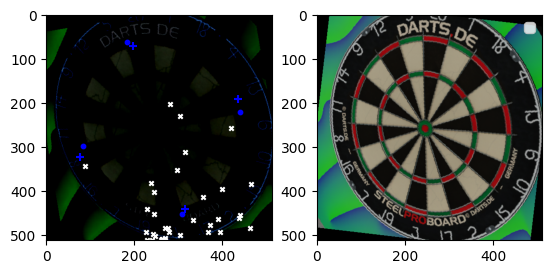

In [ ]:
model.eval()
idx = np.random.randint(len(dataset))
image, targets = dataset[idx]
src_img,_ = _dataset[idx]
images = image.unsqueeze(0).to(device)
targets = [targets]
batch_size, channels, w, h = images.shape
optimizer.zero_grad()          
outputs = model(images)
pred_classes = torch.argmax(outputs["logits"][-1, 0], dim=-1)
print()
fig, ax = plt.subplots(1, 2)
ax[0].imshow(images[0].cpu().permute(1,2,0))
ax[1].imshow(src_img.permute(1,2,0))
# ax[1].imshow(outputs["extracted_features"][-1, 0].mean(dim=0).cpu().detach())


pred_corners = outputs["points"][-1, 0][pred_classes < 4].cpu().detach()
pred_darts = outputs["points"][-1, 0][pred_classes>=4][pred_classes[pred_classes>=4]!=NUM_LABELS-1].cpu().detach()
all_darts = outputs["points"][-1, 0][pred_classes>=4].cpu().detach()

# Draw points
ax[0].scatter(pred_corners[:, 0]*w, pred_corners[:, 1]*h, color='blue', s=40, marker='+', label="pred corners")
ax[0].scatter(all_darts[:, 0]*w, all_darts[:, 1]*h, color='white', s=10, marker='x', label="all darts")
ax[0].scatter(pred_darts[:, 0]*w, pred_darts[:, 1]*h, color='red', s=40, marker='+', label="pred darts")
ax[0].scatter(targets[0]["points"][:4, 0]*w, targets[0]["points"][:4, 1]*h, color='blue', s=10, marker='o', label="gt corners")
ax[0].scatter(targets[0]["points"][4:, 0]*w, targets[0]["points"][4:, 1]*h, color='red', s=10, marker='o', label="gt darts")

# Show plot
plt.legend()
plt.show()